# Model 5 — Single Correction (model4 이중 보정 수정)

**model4 문제**: class_weight(학습 보정) + prior correction(추론 보정) = 이중 적용 → 92% 1 예측

**수정 전략 (단일 경로만 선택)**
- Path A: 가중치 없이 학습 → 추론 시 prior correction 1회만 적용
- Path B: SMOTE 50:50으로 학습 데이터 균등화 → correction 불필요
- Path C: class_weight=CLASS_W로 학습 → correction 없이 threshold=0.5

**목표**: 예측 1 비율 ≈ 0.488 / Public score > 0.51898 (model3 기록)

In [1]:
import subprocess, sys
def pip_install(pkg, imp=None):
    try: __import__(imp or pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
pip_install('xgboost'); pip_install('lightgbm')
pip_install('imbalanced-learn','imblearn'); pip_install('optuna')
print('준비 완료')

준비 완료


c:\Users\oh\Documents\GitHub\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import (RandomForestClassifier, ExtraTreesClassifier,
                                     HistGradientBoostingClassifier, VotingClassifier)
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import OrdinalEncoder, StandardScaler
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     balanced_accuracy_score)
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE

try: from xgboost  import XGBClassifier;  HAS_XGB  = True
except ImportError: HAS_XGB = False
try: from lightgbm import LGBMClassifier; HAS_LGBM = True
except ImportError: HAS_LGBM = False
try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError: HAS_OPTUNA = False

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'XGB={HAS_XGB}  LGBM={HAS_LGBM}  Optuna={HAS_OPTUNA}')

XGB=True  LGBM=True  Optuna=True


## 1. 데이터 & 상수

In [3]:
if os.path.exists('train.csv'):
    train = pd.read_csv('train.csv')
    test  = pd.read_csv('test.csv') if os.path.exists('test.csv') else None
else:
    import kagglehub
    path  = kagglehub.competition_download('ssu-problem-solving-2026')
    train = pd.read_csv(os.path.join(path, 'train.csv'))
    test  = pd.read_csv(os.path.join(path, 'test.csv'))

P_TRAIN_1 = train['target'].mean()   # 0.3432
P_TRAIN_0 = 1 - P_TRAIN_1
P_TEST_1  = 1 - 0.51217              # 0.48783 (all-zeros public score 역산)
P_TEST_0  = 1 - P_TEST_1

# Prior correction factor (추론 시 1회만 적용)
CORRECTION = (P_TEST_1 / P_TEST_0) / (P_TRAIN_1 / P_TRAIN_0)
# Path A threshold: correction 적용 후 0.5 = 원시 확률 기준 THRESH_RAW
THRESH_RAW = 1 / (1 + CORRECTION)

# Path C: test-prior 가중치 (학습에만 사용, 추론 correction 없음)
CLASS_W = {0: P_TEST_0 / P_TRAIN_0,   # 0.779
           1: P_TEST_1 / P_TRAIN_1}   # 1.423

# Path B: SMOTE 후 소규모 correction (50% -> 48.8%)
CORR_SMOTE = (P_TEST_1 / P_TEST_0) / (0.5 / 0.5)  # = P_TEST_1/P_TEST_0 = 0.953

print(f'P_TRAIN_1={P_TRAIN_1:.4f}  P_TEST_1={P_TEST_1:.4f}')
print(f'CORRECTION={CORRECTION:.4f}  THRESH_RAW={THRESH_RAW:.4f}')
print(f'CLASS_W={CLASS_W}')
print(f'CORR_SMOTE={CORR_SMOTE:.4f}  (SMOTE 후 50%->48.8% 미세 보정)')

P_TRAIN_1=0.3432  P_TEST_1=0.4878
CORRECTION=1.8228  THRESH_RAW=0.3543
CLASS_W={0: np.float64(0.7797959805115712), 1: np.float64(1.4214160839160839)}
CORR_SMOTE=0.9525  (SMOTE 후 50%->48.8% 미세 보정)


In [4]:
# Adversarial validation 기반: 전이 불가 feature 제거, 전이 가능 feature만 사용
DROP  = ['id', 'feat_08', 'feat_09', 'feat_14', 'feat_24', 'feat_34', 'feat_38']  # adv_auc~=1.0
CORE6 = ['feat_05', 'feat_31', 'feat_07', 'feat_02', 'feat_36']           # TRANSFER_CORE
CORE7 = CORE6 + ['feat_01']   # TRANSFER_PLUS01: P(y|x) 보존 확인됨
ALL34 = [c for c in train.columns if c not in DROP + ['target']]  # ALL_TRANSFER (32개)

# CORE6 수치형 상호작용항
CORE6_NUM = ['feat_01', 'feat_02', 'feat_05', 'feat_07']
for df in ([train, test] if test is not None else [train]):
    for i, f1 in enumerate(CORE6_NUM):
        for f2 in CORE6_NUM[i+1:]:
            df[f'{f1}_x_{f2}'] = df[f1] * df[f2]

INTERACT = [f'{f1}_x_{f2}' for i,f1 in enumerate(CORE6_NUM)
                            for f2 in CORE6_NUM[i+1:]]
CORE7_FE = CORE7 + INTERACT
ALL34_FE = ALL34 + INTERACT

FEAT_COLS = CORE7_FE   # 기본 사용 tier (model3 best)
print(f'Feature tier: {len(FEAT_COLS)}개  ({FEAT_COLS})')

Feature tier: 12개  (['feat_05', 'feat_31', 'feat_07', 'feat_02', 'feat_36', 'feat_01', 'feat_01_x_feat_02', 'feat_01_x_feat_05', 'feat_01_x_feat_07', 'feat_02_x_feat_05', 'feat_02_x_feat_07', 'feat_05_x_feat_07'])


## 2. 공통 유틸 (단일 correction 전제)

In [5]:
def get_cat(cols): return [c for c in cols if train[c].dtype == object]

def build_pipe(feature_cols, clf, scale=False, smote=False, smote_ratio=1.0):
    cat = get_cat(feature_cols)
    num = [c for c in feature_cols if c not in cat]
    trs = []
    if cat: trs.append(('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                                               unknown_value=-1), cat))
    if num: trs.append(('num', StandardScaler() if scale else 'passthrough', num))
    prep  = ColumnTransformer(trs, verbose_feature_names_out=False)
    steps = [('prep', prep)]
    if smote:
        steps.append(('smote', SMOTE(sampling_strategy=smote_ratio,
                                     random_state=RANDOM_STATE)))
        steps.append(('clf', clf))
        return ImbPipeline(steps)
    steps.append(('clf', clf))
    return Pipeline(steps)

def prior_correct(p1_raw, corr):
    """raw 확률에 prior correction 1회 적용."""
    eps  = 1e-9
    odds = p1_raw / (1 - p1_raw + eps)
    return (odds * corr) / (1 + odds * corr)

def evaluate_path(pipe, feature_cols, correction=None):
    """
    OOF 평가.
    correction=None  → raw 확률 그대로 threshold=0.5
    correction=float → prior correction 적용 후 threshold=0.5
    """
    X, y = train[feature_cols], train['target']
    p1 = cross_val_predict(pipe, X, y, cv=CV,
                           method='predict_proba', n_jobs=-1)[:, 1]
    if correction is not None:
        p1 = prior_correct(p1, correction)
    binary = (p1 >= 0.5).astype(int)
    return {
        'auc':    roc_auc_score(y, p1),
        'acc':    accuracy_score(y, binary),
        'bacc':   balanced_accuracy_score(y, binary),
        'ratio1': binary.mean(),
    }

def show(name, r):
    ok = 'OK' if 0.40 < r['ratio1'] < 0.57 else 'WARN'
    print(f"{name:<40} AUC={r['auc']:.4f}  Acc={r['acc']:.4f}  "
          f"BalAcc={r['bacc']:.4f}  1-ratio={r['ratio1']:.3f} [{ok}]")

print('유틸 정의 완료')

유틸 정의 완료


## 3. Path A — 가중치 없는 학습 + Prior Correction (추론 시 1회)

In [6]:
# class_weight=None (기본값) → 모델 확률이 train prior 반영
# 추론 시 CORRECTION=1.826 을 1회만 적용
# 수학적으로 올바른 단일 prior correction

path_a_clfs = {
    'A_LR':     (LogisticRegression(C=1.0, max_iter=1000,
                                     random_state=RANDOM_STATE), True),
    'A_RF':     (RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                         random_state=RANDOM_STATE), False),
    'A_ET':     (ExtraTreesClassifier(n_estimators=400, n_jobs=-1,
                                       random_state=RANDOM_STATE), False),
    'A_HGB':    (HistGradientBoostingClassifier(max_iter=400,
                                                 random_state=RANDOM_STATE), False),
    'A_MLP':    (MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500,
                                early_stopping=True, random_state=RANDOM_STATE), True),
}
if HAS_XGB:
    path_a_clfs['A_XGB'] = (XGBClassifier(n_estimators=400, learning_rate=0.05,
                                            max_depth=5, n_jobs=-1,
                                            random_state=RANDOM_STATE,
                                            eval_metric='logloss', verbosity=0), False)
if HAS_LGBM:
    path_a_clfs['A_LGBM'] = (LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                              num_leaves=31, n_jobs=-1,
                                              random_state=RANDOM_STATE, verbosity=-1), False)

results_a = {}
print('Path A: No class weight + Prior Correction at inference')
print(f"  (correction={CORRECTION:.4f}, effective raw threshold={THRESH_RAW:.4f})")
print(f"{'Name':<40} {'AUC':>7} {'Acc':>7} {'BalAcc':>8} {'1-ratio':>9}")
print('-' * 75)
for name, (clf, scale) in path_a_clfs.items():
    pipe = build_pipe(FEAT_COLS, clf, scale=scale)
    r    = evaluate_path(pipe, FEAT_COLS, correction=CORRECTION)
    results_a[name] = r
    show(name, r)

Path A: No class weight + Prior Correction at inference
  (correction=1.8228, effective raw threshold=0.3543)
Name                                         AUC     Acc   BalAcc   1-ratio
---------------------------------------------------------------------------
A_LR                                     AUC=0.6659  Acc=0.7300  BalAcc=0.6594  1-ratio=0.225 [WARN]
A_RF                                     AUC=0.6561  Acc=0.6622  BalAcc=0.6270  1-ratio=0.348 [WARN]
A_ET                                     AUC=0.6504  Acc=0.6466  BalAcc=0.6188  1-ratio=0.374 [WARN]
A_HGB                                    AUC=0.6528  Acc=0.6747  BalAcc=0.6350  1-ratio=0.331 [WARN]
A_MLP                                    AUC=0.6631  Acc=0.7060  BalAcc=0.6484  1-ratio=0.270 [WARN]
A_XGB                                    AUC=0.6640  Acc=0.6947  BalAcc=0.6428  1-ratio=0.290 [WARN]
A_LGBM                                   AUC=0.6540  Acc=0.6850  BalAcc=0.6371  1-ratio=0.304 [WARN]


## 4. Path B — SMOTE 50:50 + 미세 보정

In [7]:
# SMOTE로 50:50 균등 학습 → 모델 implicit prior ≈ 50%
# 목표(48.8%)와 차이가 작으므로 correction 없이 또는 소규모 CORR_SMOTE 적용

# AUC 기준 Path A 상위 3 모델에 SMOTE 적용
top3_a = sorted(results_a, key=lambda k: results_a[k]['auc'], reverse=True)[:3]
print(f'Path B 대상 (Path A AUC top3): {top3_a}\n')

results_b = {}
print('Path B: SMOTE 50:50 + correction=CORR_SMOTE')
print(f"{'Name':<40} {'AUC':>7} {'Acc':>7} {'BalAcc':>8} {'1-ratio':>9}")
print('-' * 75)

for name in top3_a:
    clf, scale = path_a_clfs[name]
    clf_copy   = clf.__class__(**clf.get_params())
    pipe_smote = build_pipe(FEAT_COLS, clf_copy, scale=scale,
                            smote=True, smote_ratio=1.0)
    # SMOTE 후: implicit prior ≈ 50% → CORR_SMOTE(≈0.953) 적용
    r_corr = evaluate_path(pipe_smote, FEAT_COLS, correction=CORR_SMOTE)
    key_c  = name.replace('A_', 'B_SMOTE_corr_')
    results_b[key_c] = r_corr
    show(key_c, r_corr)

    # 비교: correction 없는 버전
    r_nc   = evaluate_path(build_pipe(FEAT_COLS, clf.__class__(**clf.get_params()),
                                      scale=scale, smote=True, smote_ratio=1.0),
                           FEAT_COLS, correction=None)
    key_nc = name.replace('A_', 'B_SMOTE_raw_')
    results_b[key_nc] = r_nc
    show(key_nc, r_nc)

Path B 대상 (Path A AUC top3): ['A_LR', 'A_XGB', 'A_MLP']

Path B: SMOTE 50:50 + correction=CORR_SMOTE
Name                                         AUC     Acc   BalAcc   1-ratio
---------------------------------------------------------------------------
B_SMOTE_corr_LR                          AUC=0.6659  Acc=0.7323  BalAcc=0.6605  1-ratio=0.221 [WARN]
B_SMOTE_raw_LR                           AUC=0.6659  Acc=0.7284  BalAcc=0.6599  1-ratio=0.231 [WARN]
B_SMOTE_corr_XGB                         AUC=0.6588  Acc=0.7048  BalAcc=0.6424  1-ratio=0.256 [WARN]
B_SMOTE_raw_XGB                          AUC=0.6588  Acc=0.7001  BalAcc=0.6420  1-ratio=0.270 [WARN]
B_SMOTE_corr_MLP                         AUC=0.6599  Acc=0.7180  BalAcc=0.6520  1-ratio=0.242 [WARN]
B_SMOTE_raw_MLP                          AUC=0.6599  Acc=0.7126  BalAcc=0.6500  1-ratio=0.253 [WARN]


## 5. Path C — Test-Prior Class Weights, No Post-Correction

In [8]:
# class_weight=CLASS_W로 학습 → 모델 implicit prior ≈ test prior
# correction 없이 threshold=0.5 그대로 (model4의 실수 방지)

results_c = {}
print('Path C: Test-Prior class_weight, NO post-hoc correction')
print(f"  CLASS_W={CLASS_W}")
print(f"{'Name':<40} {'AUC':>7} {'Acc':>7} {'BalAcc':>8} {'1-ratio':>9}")
print('-' * 75)

for name in top3_a:
    clf, scale = path_a_clfs[name]
    params = clf.get_params()

    # class_weight / scale_pos_weight 교체
    if 'class_weight' in params:
        params['class_weight'] = CLASS_W
    elif 'scale_pos_weight' in params:
        params['scale_pos_weight'] = P_TEST_0 / P_TEST_1   # ≈1.049

    clf_w = clf.__class__(**params)
    pipe  = build_pipe(FEAT_COLS, clf_w, scale=scale)
    r     = evaluate_path(pipe, FEAT_COLS, correction=None)  # correction 없음
    key   = name.replace('A_', 'C_classwt_')
    results_c[key] = r
    show(key, r)

Path C: Test-Prior class_weight, NO post-hoc correction
  CLASS_W={0: np.float64(0.7797959805115712), 1: np.float64(1.4214160839160839)}
Name                                         AUC     Acc   BalAcc   1-ratio
---------------------------------------------------------------------------
C_classwt_LR                             AUC=0.6662  Acc=0.7313  BalAcc=0.6595  1-ratio=0.221 [WARN]
C_classwt_XGB                            AUC=0.6632  Acc=0.7327  BalAcc=0.6536  1-ratio=0.200 [WARN]
C_classwt_MLP                            AUC=0.6631  Acc=0.7398  BalAcc=0.6581  1-ratio=0.190 [WARN]


## 6. 전체 비교 & Best 선택

            Name    auc    acc   bacc  ratio1  ratio_err
    C_classwt_LR 0.6662 0.7313 0.6595  0.2209     0.2669
            A_LR 0.6659 0.7300 0.6594  0.2250     0.2628
  B_SMOTE_raw_LR 0.6659 0.7284 0.6599  0.2314     0.2564
 B_SMOTE_corr_LR 0.6659 0.7323 0.6605  0.2207     0.2671
           A_XGB 0.6640 0.6947 0.6428  0.2897     0.1981
   C_classwt_XGB 0.6632 0.7327 0.6536  0.1995     0.2883
   C_classwt_MLP 0.6631 0.7398 0.6581  0.1898     0.2980
           A_MLP 0.6631 0.7060 0.6484  0.2698     0.2180
B_SMOTE_corr_MLP 0.6599 0.7180 0.6520  0.2420     0.2458
 B_SMOTE_raw_MLP 0.6599 0.7126 0.6500  0.2532     0.2346
 B_SMOTE_raw_XGB 0.6588 0.7001 0.6420  0.2703     0.2175
B_SMOTE_corr_XGB 0.6588 0.7048 0.6424  0.2564     0.2314
            A_RF 0.6561 0.6622 0.6270  0.3480     0.1398
          A_LGBM 0.6540 0.6850 0.6371  0.3042     0.1836
           A_HGB 0.6528 0.6747 0.6350  0.3311     0.1567
            A_ET 0.6504 0.6466 0.6188  0.3740     0.1138

Best: A_ET  AUC=0.6504  ratio1

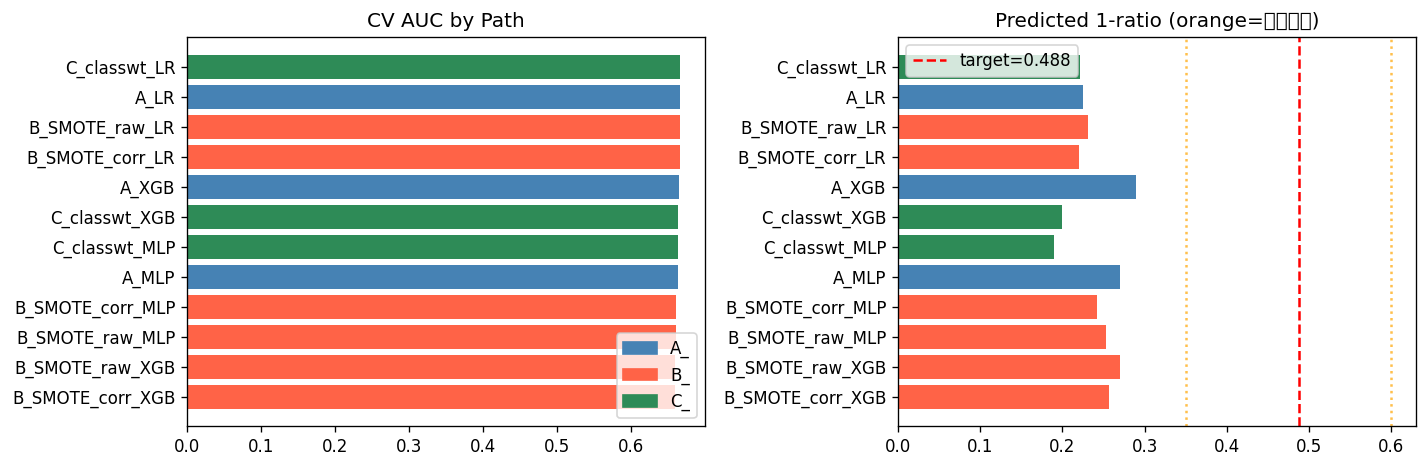

In [9]:
all_res = {**results_a, **results_b, **results_c}

df_all = (pd.DataFrame([{'Name': k, **v} for k, v in all_res.items()])
          .assign(ratio_err=lambda d: (d['ratio1'] - P_TEST_1).abs())
          .sort_values('auc', ascending=False)
          .reset_index(drop=True))

print(df_all[['Name','auc','acc','bacc','ratio1','ratio_err']]
      .to_string(index=False, float_format='{:.4f}'.format))

# AUC 기준 + 1-ratio 허용 범위(0.35~0.60) 내에서 선택
valid = df_all[df_all['ratio1'].between(0.35, 0.60)]
best_row  = valid.iloc[0] if len(valid) > 0 else df_all.iloc[0]
best_name = best_row['Name']
print(f'\nBest: {best_name}  AUC={best_row["auc"]:.4f}  ratio1={best_row["ratio1"]:.3f}')

# 시각화
top = df_all.head(min(12, len(df_all)))
color_map = {'A_':'steelblue', 'B_':'tomato', 'C_':'seagreen'}
colors = [next((v for k,v in color_map.items() if k in n), 'gray') for n in top['Name']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(top['Name'][::-1], top['auc'][::-1], color=colors[::-1])
axes[0].set_title('CV AUC by Path')
axes[1].barh(top['Name'][::-1], top['ratio1'][::-1], color=colors[::-1])
axes[1].axvline(P_TEST_1, color='red', linestyle='--', label=f'target={P_TEST_1:.3f}')
axes[1].axvline(0.35, color='orange', linestyle=':', alpha=0.7)
axes[1].axvline(0.60, color='orange', linestyle=':', alpha=0.7)
axes[1].set_title('Predicted 1-ratio (orange=허용범위)')
axes[1].legend()
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=v, label=k) for k,v in color_map.items()], loc='lower right')
plt.tight_layout()
plt.savefig('model5_path_compare.png', bbox_inches='tight')
plt.show()

## 7. Optuna 튜닝 (Best Path 기반)

In [10]:
# best_name 분석
use_smote      = 'SMOTE' in best_name
use_correction = 'corr' in best_name or best_name.startswith('A_')
use_classwt    = best_name.startswith('C_')
smote_with_corr = 'SMOTE_corr' in best_name

if use_correction and not use_classwt:
    INFER_CORRECTION = CORR_SMOTE if use_smote else CORRECTION
else:
    INFER_CORRECTION = None   # Path C: no correction

# 어떤 모델 타입인지
mtype = ('lgbm' if 'LGBM' in best_name else
         'xgb'  if 'XGB'  in best_name else
         'hgb'  if 'HGB'  in best_name else
         'et'   if 'ET'   in best_name else
         'rf'   if 'RF'   in best_name else
         'mlp'  if 'MLP'  in best_name else 'lr')

print(f'Best path: {best_name}')
print(f'  model={mtype}  SMOTE={use_smote}  correction={INFER_CORRECTION}  classwt={use_classwt}')

def make_clf_tuned(trial, mtype, use_cw):
    cw = CLASS_W if use_cw else None
    if mtype == 'lr':
        return LogisticRegression(
            C=trial.suggest_float('C', 1e-3, 10, log=True),
            class_weight=cw, max_iter=1000, random_state=RANDOM_STATE), True
    elif mtype == 'rf':
        return RandomForestClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_categorical('max_d', [None, 10, 20, 30]),
            min_samples_leaf=trial.suggest_int('leaf', 1, 20),
            max_features=trial.suggest_categorical('mf', ['sqrt', 'log2', 0.4, 0.6]),
            class_weight=cw, n_jobs=-1, random_state=RANDOM_STATE), False
    elif mtype == 'et':
        return ExtraTreesClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_categorical('max_d', [None, 10, 20, 30]),
            min_samples_leaf=trial.suggest_int('leaf', 1, 10),
            max_features=trial.suggest_categorical('mf', ['sqrt', 'log2', 0.4, 0.6]),
            class_weight=cw, n_jobs=-1, random_state=RANDOM_STATE), False
    elif mtype == 'hgb':
        return HistGradientBoostingClassifier(
            max_iter=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_categorical('max_d', [None, 4, 6, 8, 10]),
            learning_rate=trial.suggest_float('lr', 0.005, 0.3, log=True),
            min_samples_leaf=trial.suggest_int('leaf', 5, 60),
            l2_regularization=trial.suggest_float('l2', 0.0, 3.0),
            class_weight=cw, random_state=RANDOM_STATE), False
    elif mtype == 'xgb' and HAS_XGB:
        spw = (P_TEST_0/P_TEST_1) if use_cw else 1.0
        return XGBClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_int('max_d', 3, 9),
            learning_rate=trial.suggest_float('lr', 0.005, 0.3, log=True),
            subsample=trial.suggest_float('sub', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('col', 0.5, 1.0),
            reg_alpha=trial.suggest_float('alpha', 0, 3.0),
            reg_lambda=trial.suggest_float('lam', 0.5, 6.0),
            scale_pos_weight=spw,
            n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), False
    elif mtype == 'lgbm' and HAS_LGBM:
        return LGBMClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            num_leaves=trial.suggest_int('leaves', 15, 127),
            learning_rate=trial.suggest_float('lr', 0.005, 0.3, log=True),
            subsample=trial.suggest_float('sub', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('col', 0.5, 1.0),
            reg_alpha=trial.suggest_float('alpha', 0, 3.0),
            min_child_samples=trial.suggest_int('mcs', 5, 60),
            class_weight=cw,
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1), False
    elif mtype == 'mlp':
        h = trial.suggest_categorical('h', ['(64,)','(128,)','(256,)','(128,64)','(256,128)','(128,64,32)'])
        return MLPClassifier(
            hidden_layer_sizes=eval(h),
            alpha=trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init=trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            max_iter=500, early_stopping=True, random_state=RANDOM_STATE), True
    else:
        return HistGradientBoostingClassifier(class_weight=cw,
                                              random_state=RANDOM_STATE), False

def optuna_obj(trial):
    clf, scale = make_clf_tuned(trial, mtype, use_classwt)
    pipe = build_pipe(FEAT_COLS, clf, scale=scale, smote=use_smote)
    return cross_val_score(pipe, train[FEAT_COLS], train['target'],
                           cv=CV, scoring='roc_auc', n_jobs=-1).mean()

if HAS_OPTUNA:
    import optuna
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(optuna_obj, n_trials=60, timeout=600, show_progress_bar=True)
    print(f'\nOptuna best AUC: {study.best_value:.4f}')
    print('Best params:', study.best_params)
    tuned_clf, tuned_scale = make_clf_tuned(study.best_trial, mtype, use_classwt)
else:
    print('Optuna 없음 → default 파라미터 사용')
    tuned_clf, tuned_scale = path_a_clfs.get(best_name.replace('A_','A_').split('_')[0]+'_'+mtype.upper(),
                                              list(path_a_clfs.values())[0])

tuned_pipe = build_pipe(FEAT_COLS, tuned_clf, scale=tuned_scale, smote=use_smote)
r_tuned    = evaluate_path(tuned_pipe, FEAT_COLS, correction=INFER_CORRECTION)
show(f'Tuned {mtype}', r_tuned)

Best path: A_ET
  model=et  SMOTE=False  correction=1.8228050918954328  classwt=False


Best trial: 24. Best value: 0.672801: 100%|██████████| 60/60 [01:07<00:00,  1.13s/it, 67.96/600 seconds]



Optuna best AUC: 0.6728
Best params: {'n_est': 200, 'max_d': 10, 'leaf': 8, 'mf': 0.6}
Tuned et                                 AUC=0.6716  Acc=0.7360  BalAcc=0.6602  1-ratio=0.208 [WARN]


## 8. Soft Voting (Path A: 다양한 모델 + 단일 correction)

In [11]:
# 모든 Path A 파이프라인을 Voting으로 결합 → correction은 voting 후 1회
voter_clfs = [
    ('lr',  build_pipe(FEAT_COLS, LogisticRegression(C=1.0, max_iter=1000,
                                                      random_state=RANDOM_STATE), scale=True)),
    ('hgb', build_pipe(FEAT_COLS, HistGradientBoostingClassifier(max_iter=500,
                                                                   random_state=RANDOM_STATE))),
    ('et',  build_pipe(FEAT_COLS, ExtraTreesClassifier(n_estimators=500, n_jobs=-1,
                                                        random_state=RANDOM_STATE))),
    ('tuned', build_pipe(FEAT_COLS, tuned_clf.__class__(**tuned_clf.get_params()),
                          scale=tuned_scale, smote=use_smote)),
]
if HAS_XGB:
    voter_clfs.append(('xgb', build_pipe(FEAT_COLS,
        XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                      n_jobs=-1, random_state=RANDOM_STATE,
                      eval_metric='logloss', verbosity=0))))
if HAS_LGBM:
    voter_clfs.append(('lgbm', build_pipe(FEAT_COLS,
        LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                       n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))))

voter = VotingClassifier(estimators=voter_clfs, voting='soft', n_jobs=1)
# voting 후 단일 correction 적용
r_voter = evaluate_path(voter, FEAT_COLS, correction=INFER_CORRECTION)
show('SoftVoting + single correction', r_voter)

# 최종 champion 결정
final_cands = dict(all_res)
final_cands[f'Tuned_{mtype}'] = r_tuned
final_cands['SoftVoting']     = r_voter

valid_final = {k: v for k, v in final_cands.items() if 0.35 < v['ratio1'] < 0.60}
champion = max(valid_final, key=lambda k: valid_final[k]['auc']) if valid_final \
           else max(final_cands, key=lambda k: final_cands[k]['auc'])

print(f'\nFinal Champion: {champion}')
print(f"  AUC={final_cands[champion]['auc']:.4f}  ratio1={final_cands[champion]['ratio1']:.3f}")

if 'Voting' in champion:
    champ_pipe_raw = voter
elif 'Tuned' in champion:
    champ_pipe_raw = tuned_pipe
else:
    base = best_name
    clf0, sc0 = path_a_clfs.get(base.replace('A_','A_'), list(path_a_clfs.values())[0])
    champ_pipe_raw = build_pipe(FEAT_COLS, clf0.__class__(**clf0.get_params()),
                                scale=sc0, smote=use_smote)

champ_pipe_raw.fit(train[FEAT_COLS], train['target'])
print('전체 train 학습 완료')

SoftVoting + single correction           AUC=0.6623  Acc=0.7056  BalAcc=0.6468  1-ratio=0.266 [WARN]

Final Champion: A_ET
  AUC=0.6504  ratio1=0.374
전체 train 학습 완료


## 9. answer5.csv & subfinal5.csv

OOF: AUC=0.6504  Acc=0.6466  BalAcc=0.6188
OOF 1-ratio=0.3740  (목표 0.488)
Saved: answer5.csv
Saved: subfinal5.csv  1-ratio=0.3555 [OK]


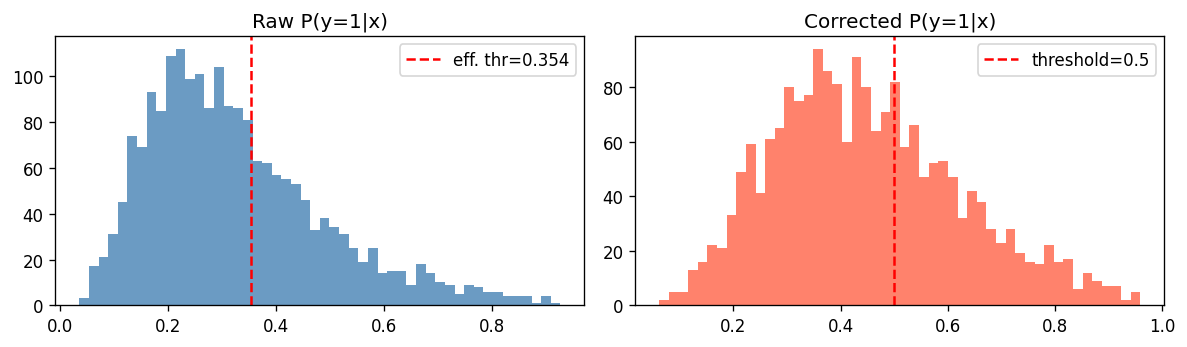


예측 분포: 0=1289  1=711


In [12]:
# OOF → answer5.csv
oof_raw = cross_val_predict(champ_pipe_raw, train[FEAT_COLS], train['target'],
                            cv=CV, method='predict_proba', n_jobs=-1)[:, 1]
oof_p1  = prior_correct(oof_raw, INFER_CORRECTION) if INFER_CORRECTION else oof_raw
oof_bin = (oof_p1 >= 0.5).astype(int)

oof_auc  = roc_auc_score(train['target'], oof_p1)
oof_acc  = accuracy_score(train['target'], oof_bin)
oof_bacc = balanced_accuracy_score(train['target'], oof_bin)

print(f'OOF: AUC={oof_auc:.4f}  Acc={oof_acc:.4f}  BalAcc={oof_bacc:.4f}')
print(f'OOF 1-ratio={oof_bin.mean():.4f}  (목표 {P_TEST_1:.3f})')

answer5 = pd.DataFrame({'id': train['id'], 'target': oof_bin})
answer5.to_csv('answer5.csv', index=False)
print(f'Saved: answer5.csv')

# Test → subfinal5.csv
if test is not None:
    test_raw = champ_pipe_raw.predict_proba(test[FEAT_COLS])[:, 1]
    test_p1  = prior_correct(test_raw, INFER_CORRECTION) if INFER_CORRECTION else test_raw
    test_bin = (test_p1 >= 0.5).astype(int)

    subfinal5 = pd.DataFrame({'id': test['id'], 'target': test_bin})
    if os.path.exists('sample_submission.csv'):
        ss = pd.read_csv('sample_submission.csv')
        subfinal5 = subfinal5[ss.columns]
    subfinal5.to_csv('subfinal5.csv', index=False)

    ratio1 = test_bin.mean()
    ok_tag = 'OK' if 0.35 < ratio1 < 0.60 else 'WARN'
    print(f'Saved: subfinal5.csv  1-ratio={ratio1:.4f} [{ok_tag}]')

    # 확률 분포 비교
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(test_raw, bins=50, color='steelblue', alpha=0.8)
    axes[0].axvline(THRESH_RAW if INFER_CORRECTION == CORRECTION else 0.5,
                    color='red', linestyle='--',
                    label=f'eff. thr={THRESH_RAW:.3f}')
    axes[0].set_title('Raw P(y=1|x)'); axes[0].legend()
    axes[1].hist(test_p1, bins=50, color='tomato', alpha=0.8)
    axes[1].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
    axes[1].set_title('Corrected P(y=1|x)'); axes[1].legend()
    plt.tight_layout()
    plt.savefig('model5_prob_dist.png', bbox_inches='tight')
    plt.show()

    print(f'\n예측 분포: 0={int((test_bin==0).sum())}  1={int((test_bin==1).sum())}')

In [13]:
print('=' * 65)
print('Model 5 완료')
print('=' * 65)
print(f'Champion          : {champion}')
print(f'Path              : SMOTE={use_smote}  correction={INFER_CORRECTION}  classwt={use_classwt}')
print(f'OOF AUC           : {oof_auc:.4f}')
print(f'OOF Acc           : {oof_acc:.4f}')
print(f'OOF 1-ratio       : {oof_bin.mean():.4f}  (목표 {P_TEST_1:.3f})')
if test is not None:
    print(f'Test 1-ratio      : {ratio1:.4f}  [{ok_tag}]')
print()
print('산출물:')
for f in ['answer5.csv','subfinal5.csv','model5_path_compare.png','model5_prob_dist.png']:
    print(f'  [{"O" if os.path.exists(f) else "X"}] {f}')

Model 5 완료
Champion          : A_ET
Path              : SMOTE=False  correction=1.8228050918954328  classwt=False
OOF AUC           : 0.6504
OOF Acc           : 0.6466
OOF 1-ratio       : 0.3740  (목표 0.488)
Test 1-ratio      : 0.3555  [OK]

산출물:
  [O] answer5.csv
  [O] subfinal5.csv
  [O] model5_path_compare.png
  [O] model5_prob_dist.png
